In [1]:
import matplotlib
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import cupy
import os

kaggle = True if os.environ.get('KAGGLE_URL_BASE','') else False
balanced = False
testing_mode = True
selected_features = False
cat_features = False

if kaggle:
    training_data = '/kaggle/input/competitions/playground-series-s6e4/train.csv'
else:
    training_data = 'data/train.csv'

df_tv = pd.read_csv(training_data)
df_x = df_tv.iloc[:,1:-1]

#df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)
if cat_features:
    categorical_cols = df_x.select_dtypes(['object']).columns
    df_x[categorical_cols] = df_x[categorical_cols].astype('category')
    df_dummy = df_x
    print(categorical_cols)
else:
    df_dummy = pd.get_dummies(df_x, dtype=int, drop_first=False)

if selected_features:
    df_label = df_tv.replace({'Irrigation_Need': {'Low': 0, 'Medium': 1, 'High': 2}})['Irrigation_Need']
    df_full = pd.concat([df_dummy, df_label], axis=1)
    corr = df_full.corr()
    df_corr_sort_abs = corr.abs().sort_values(by='Irrigation_Need', ascending=False)['Irrigation_Need']
    threshold = 0.1
    df_dummy = df_full[df_corr_sort_abs[df_corr_sort_abs > threshold].index]
    df_dummy.drop(columns=['Irrigation_Need'], inplace=True)
newcolumns = df_dummy.columns.values.tolist() + ['Irrigation_Need']
continous_variables = df_dummy.select_dtypes(['float64']).columns
index = [df_dummy.columns.get_loc(col) for col in continous_variables]

x = df_dummy.iloc[:,:].values
y = df_tv.iloc[:,-1].values

class_le = LabelEncoder()
y = class_le.fit_transform(y)

if testing_mode:
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = \
        train_test_split(x, y, 
                        test_size=0.20,
                        stratify=y,
                        random_state=1)
else:
    X_train, y_train = x, y

sc = StandardScaler().fit(X_train[:, index])
X_train[:, index] = sc.transform(X_train[:, index])

if testing_mode:
    X_test[:, index] = sc.transform(X_test[:, index])


if balanced:
    majority_class = np.argmax(np.bincount(y_train))
    minority_class = np.argmin(np.bincount(y_train))
    middle_class = list(set(np.unique(y_train)) - set([majority_class, minority_class]))[0]
    X_train_majority = X_train[y_train == majority_class]
    y_train_majority = y_train[y_train == majority_class]
    
    X_train_minority = X_train[y_train == minority_class]
    y_train_minority = y_train[y_train == minority_class]
    
    X_train_middle = X_train[y_train == middle_class]
    y_train_middle = y_train[y_train == middle_class]
    
    
    X_train_minority_upsampled, y_train_minority_upsampled = resample(X_train_minority, y_train_minority,
                                                                      replace=True,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_majority_downsampled, y_train_majority_downsampled = resample(X_train_majority, y_train_majority,
                                                                      replace=False,
                                                                      n_samples=X_train_middle.shape[0],
                                                                      random_state=1)
    X_train_balanced = np.vstack((X_train_majority_downsampled, X_train_middle, X_train_minority_upsampled))
    y_train_balanced = np.hstack((y_train_majority_downsampled, y_train_middle, y_train_minority_upsampled))

    perm = np.random.permutation(len(X_train_balanced))

    X_train = X_train_balanced[perm]
    y_train = y_train_balanced[perm]

    train_features = np.hstack((X_train, y_train.reshape(-1, 1)))

    df_train = pd.DataFrame(train_features, columns=newcolumns)





In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# fit the model
model = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
yhat = model.fit_predict(x)

# identify outliers
mask = yhat == -1
outliers = x[mask]

print(f'Number of outliers detected: {len(outliers)}')
print('Outliers:\n', outliers)

# identify inliers
mask = yhat == 1
inliers_x = x[mask]
inliers_y = y[mask]
print(x.shape, y.shape)
print(inliers_x.shape, inliers_y.shape)

if inliers: x, y = inliers_x, inliers_y

Number of outliers detected: 50400
Outliers:
 [[-1.56413941  0.82929717  0.75806891 ...  0.          0.
   0.        ]
 [-1.78104582 -0.09733778 -0.00755862 ...  0.          0.
   0.        ]
 [-0.56636991  1.68878465  0.15650442 ...  0.          0.
   0.        ]
 ...
 [ 1.65692082 -0.73035519  1.2229142  ...  0.          0.
   0.        ]
 [ 1.00620159 -0.9653713   1.05885116 ...  0.          0.
   0.        ]
 [ 1.76537403  0.38673436  1.71510332 ...  0.          0.
   0.        ]]


In [4]:
df_train[mask,:]

NameError: name 'df_train' is not defined

In [ ]:
X_train[0,:]

In [3]:
df_tv.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [ ]:
df_dummy.describe()

In [8]:
df_label = df_tv.replace({'Irrigation_Need': {'Low': 0, 'Medium': 1, 'High': 2}})['Irrigation_Need']
df_full = pd.concat([df_dummy, df_label], axis=1)
corr = df_full.corr()

/tmp/ipykernel_98128/1666513542.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_label = df_tv.replace({'Irrigation_Need': {'Low': 0, 'Medium': 1, 'High': 2}})['Irrigation_Need']


In [9]:
corr
#corr.style.background_gradient(cmap='coolwarm')

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West,Irrigation_Need
Soil_pH,1.000000,-0.003547,-0.002973,-0.000171,-0.002402,0.001374,-0.004799,0.000586,0.002978,0.004335,...,-3.735209e-04,0.002523,-0.002063,0.002063,-0.000746,0.001536,-4.214516e-04,0.000185,-0.000571,0.000150
Soil_Moisture,-0.003547,1.000000,-0.015072,-0.009136,-0.037891,0.015403,0.044473,0.005776,-0.027865,-0.005365,...,-1.094309e-02,-0.012455,-0.042919,0.042919,0.002606,0.001409,-1.425752e-03,-0.000543,-0.002037,-0.455482
Organic_Carbon,-0.002973,-0.015072,1.000000,0.010919,-0.001954,0.003093,-0.017391,-0.000438,0.011341,-0.006283,...,3.701882e-03,-0.001527,-0.000611,0.000611,-0.000622,0.000126,1.172655e-03,-0.000462,-0.000161,0.006451
Electrical_Conductivity,-0.000171,-0.009136,0.010919,1.000000,0.003641,0.000256,-0.004025,0.000111,-0.001637,0.007656,...,6.257643e-03,-0.000742,0.004239,-0.004239,0.000995,-0.000821,-5.111911e-04,-0.000075,0.000397,0.010785
Temperature_C,-0.002402,-0.037891,-0.001954,0.003641,1.000000,-0.020448,-0.016767,-0.003049,-0.002041,0.010836,...,1.465374e-03,0.012324,0.005595,-0.005595,-0.001555,-0.003593,4.864001e-03,0.003922,-0.003513,0.252867
Humidity,0.001374,0.015403,0.003093,0.000256,-0.020448,1.000000,0.000596,0.001786,0.011738,0.005706,...,-3.963141e-03,0.006009,-0.011507,0.011507,-0.000463,0.002233,-2.701573e-03,-0.002183,0.003020,-0.021870
Rainfall_mm,-0.004799,0.044473,-0.017391,-0.004025,-0.016767,0.000596,1.000000,-0.006219,-0.032776,-0.011578,...,9.051486e-03,-0.003394,-0.006414,0.006414,0.000020,0.005252,-1.125421e-03,-0.004148,0.000061,-0.111478
Sunlight_Hours,0.000586,0.005776,-0.000438,0.000111,-0.003049,0.001786,-0.006219,1.000000,0.000134,-0.004999,...,-1.107488e-02,0.003829,0.001058,-0.001058,0.001223,0.000735,-7.685488e-05,0.001342,-0.003203,-0.000313
Wind_Speed_kmh,0.002978,-0.027865,0.011341,-0.001637,-0.002041,0.011738,-0.032776,0.000134,1.000000,0.009671,...,-5.224182e-03,0.000430,0.019751,-0.019751,0.002394,-0.001427,1.057564e-03,0.001012,-0.002961,0.258170
Field_Area_hectare,0.004335,-0.005365,-0.006283,0.007656,0.010836,0.005706,-0.011578,-0.004999,0.009671,1.000000,...,1.895572e-04,0.005668,-0.003502,0.003502,0.002332,0.001571,-6.208679e-05,-0.000757,-0.003007,0.017699


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.matshow(corr)


<Axes: >

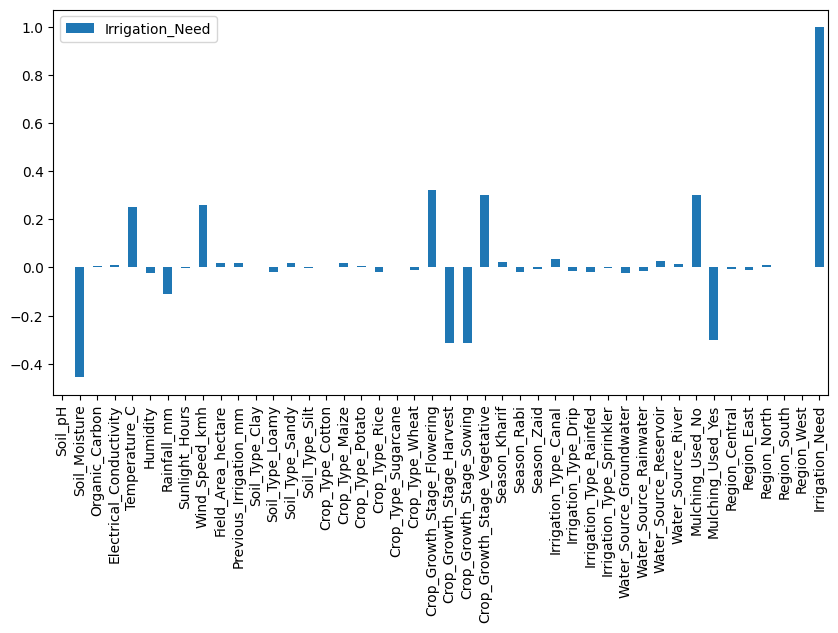

In [10]:
corr.plot(kind='bar', y='Irrigation_Need', figsize=(10,5))

In [11]:
df_corr_sort = corr.sort_values(by='Irrigation_Need', ascending=False)['Irrigation_Need']
df_corr_sort

Irrigation_Need                 1.000000
Crop_Growth_Stage_Flowering     0.321888
Crop_Growth_Stage_Vegetative    0.302851
Mulching_Used_No                0.300043
Wind_Speed_kmh                  0.258170
Temperature_C                   0.252867
Irrigation_Type_Canal           0.035745
Water_Source_Reservoir          0.025116
Season_Kharif                   0.022350
Crop_Type_Maize                 0.020588
Previous_Irrigation_mm          0.019637
Field_Area_hectare              0.017699
Soil_Type_Sandy                 0.017301
Water_Source_River              0.014824
Electrical_Conductivity         0.010785
Region_North                    0.009947
Organic_Carbon                  0.006451
Crop_Type_Potato                0.004197
Region_West                     0.002445
Crop_Type_Cotton                0.002198
Soil_Type_Clay                  0.001980
Region_South                    0.001908
Soil_pH                         0.000150
Crop_Type_Sugarcane             0.000081
Sunlight_Hours  

In [12]:
df_corr_sort_all = corr.sort_values(by='Irrigation_Need', ascending=False)
df_corr_sort_all

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West,Irrigation_Need
Irrigation_Need,0.000150,-0.455482,0.006451,0.010785,0.252867,-0.021870,-0.111478,-0.000313,0.258170,0.017699,...,2.511594e-02,0.014824,0.300043,-0.300043,-0.004269,-0.009772,9.947359e-03,0.001908,0.002445,1.000000
Crop_Growth_Stage_Flowering,0.003539,-0.040195,0.000698,0.002954,0.026455,-0.027290,-0.017437,-0.004189,0.015426,0.004241,...,1.043832e-02,-0.002584,0.052942,-0.052942,-0.003362,-0.003877,6.307871e-03,0.002398,-0.001294,0.321888
Crop_Growth_Stage_Vegetative,-0.007008,-0.082527,-0.002327,0.006419,0.001079,-0.040751,-0.017974,0.014716,0.017690,0.004454,...,1.333430e-03,-0.000416,0.007030,-0.007030,-0.004128,-0.000219,-4.692266e-03,0.007272,0.001361,0.302851
Mulching_Used_No,-0.002063,-0.042919,-0.000611,0.004239,0.005595,-0.011507,-0.006414,0.001058,0.019751,-0.003502,...,3.538161e-03,0.007835,1.000000,-1.000000,0.006119,-0.006310,1.316591e-02,-0.015160,0.003056,0.300043
Wind_Speed_kmh,0.002978,-0.027865,0.011341,-0.001637,-0.002041,0.011738,-0.032776,0.000134,1.000000,0.009671,...,-5.224182e-03,0.000430,0.019751,-0.019751,0.002394,-0.001427,1.057564e-03,0.001012,-0.002961,0.258170
Temperature_C,-0.002402,-0.037891,-0.001954,0.003641,1.000000,-0.020448,-0.016767,-0.003049,-0.002041,0.010836,...,1.465374e-03,0.012324,0.005595,-0.005595,-0.001555,-0.003593,4.864001e-03,0.003922,-0.003513,0.252867
Irrigation_Type_Canal,0.000132,-0.028566,0.003941,0.001232,0.003131,-0.032425,-0.007549,0.011894,0.010250,0.014862,...,1.586666e-02,0.005149,0.031626,-0.031626,-0.002014,0.008223,-7.243483e-03,-0.002763,0.003527,0.035745
Water_Source_Reservoir,-0.000374,-0.010943,0.003702,0.006258,0.001465,-0.003963,0.009051,-0.011075,-0.005224,0.000190,...,1.000000e+00,-0.344434,0.003538,-0.003538,0.003167,-0.002563,-9.318215e-08,0.000929,-0.001511,0.025116
Season_Kharif,-0.013505,-0.015984,0.011180,-0.002480,0.002360,-0.007308,-0.007216,-0.007428,-0.001483,-0.010746,...,1.020456e-02,0.002416,0.028541,-0.028541,0.007725,-0.005263,6.239902e-03,-0.001551,-0.006724,0.022350
Crop_Type_Maize,0.001941,-0.003540,0.003351,0.002045,0.001110,0.008360,0.002143,-0.001208,0.012834,-0.000742,...,1.591298e-03,0.000105,0.014620,-0.014620,0.003074,-0.001289,-6.171116e-04,-0.001456,0.000319,0.020588


In [15]:
df_corr_all_abs = corr.abs()
# df_selected = df_full[df_corr_sort_abs.index[:10]]
# df_selected.head()
df_corr_all_abs

# threshold = 0.1
# df_selected_all = df_full[df_corr_sort__all_abs[df_corr_sort__all_abs > threshold].index]
# df_selected_all.head()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,...,Water_Source_Reservoir,Water_Source_River,Mulching_Used_No,Mulching_Used_Yes,Region_Central,Region_East,Region_North,Region_South,Region_West,Irrigation_Need
Soil_pH,1.000000,0.003547,0.002973,0.000171,0.002402,0.001374,0.004799,0.000586,0.002978,0.004335,...,3.735209e-04,0.002523,0.002063,0.002063,0.000746,0.001536,4.214516e-04,0.000185,0.000571,0.000150
Soil_Moisture,0.003547,1.000000,0.015072,0.009136,0.037891,0.015403,0.044473,0.005776,0.027865,0.005365,...,1.094309e-02,0.012455,0.042919,0.042919,0.002606,0.001409,1.425752e-03,0.000543,0.002037,0.455482
Organic_Carbon,0.002973,0.015072,1.000000,0.010919,0.001954,0.003093,0.017391,0.000438,0.011341,0.006283,...,3.701882e-03,0.001527,0.000611,0.000611,0.000622,0.000126,1.172655e-03,0.000462,0.000161,0.006451
Electrical_Conductivity,0.000171,0.009136,0.010919,1.000000,0.003641,0.000256,0.004025,0.000111,0.001637,0.007656,...,6.257643e-03,0.000742,0.004239,0.004239,0.000995,0.000821,5.111911e-04,0.000075,0.000397,0.010785
Temperature_C,0.002402,0.037891,0.001954,0.003641,1.000000,0.020448,0.016767,0.003049,0.002041,0.010836,...,1.465374e-03,0.012324,0.005595,0.005595,0.001555,0.003593,4.864001e-03,0.003922,0.003513,0.252867
Humidity,0.001374,0.015403,0.003093,0.000256,0.020448,1.000000,0.000596,0.001786,0.011738,0.005706,...,3.963141e-03,0.006009,0.011507,0.011507,0.000463,0.002233,2.701573e-03,0.002183,0.003020,0.021870
Rainfall_mm,0.004799,0.044473,0.017391,0.004025,0.016767,0.000596,1.000000,0.006219,0.032776,0.011578,...,9.051486e-03,0.003394,0.006414,0.006414,0.000020,0.005252,1.125421e-03,0.004148,0.000061,0.111478
Sunlight_Hours,0.000586,0.005776,0.000438,0.000111,0.003049,0.001786,0.006219,1.000000,0.000134,0.004999,...,1.107488e-02,0.003829,0.001058,0.001058,0.001223,0.000735,7.685488e-05,0.001342,0.003203,0.000313
Wind_Speed_kmh,0.002978,0.027865,0.011341,0.001637,0.002041,0.011738,0.032776,0.000134,1.000000,0.009671,...,5.224182e-03,0.000430,0.019751,0.019751,0.002394,0.001427,1.057564e-03,0.001012,0.002961,0.258170
Field_Area_hectare,0.004335,0.005365,0.006283,0.007656,0.010836,0.005706,0.011578,0.004999,0.009671,1.000000,...,1.895572e-04,0.005668,0.003502,0.003502,0.002332,0.001571,6.208679e-05,0.000757,0.003007,0.017699


In [ ]:
df_corr_sort_abs = corr.abs().sort_values(by='Irrigation_Need', ascending=False)['Irrigation_Need']
# df_selected = df_full[df_corr_sort_abs.index[:10]]
# df_selected.head()
df_corr_sort_abs

In [ ]:
threshold = 0.1
df_selected = df_full[df_corr_sort_abs[df_corr_sort_abs > threshold].index]
df_selected.head()

In [ ]:
import autoviz as av
#%matplotlib inline
dft_eda = av.AutoViz_Class()
dft_eda.AutoViz(filename='', dfte=df_tv, depVar='Irrigation_Need', 
verbose=2, lowess=False, chart_format='svg', max_rows_analyzed=1000, save_plot_dir="./autoviz_plots/")


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df_tv, title="Profiling Report")
#profile.to_notebook_iframe()

In [ ]:





# df_tv = pd.read_csv(training_data)
# counts = df_tv['Irrigation_Need'].value_counts()
# continous_variables = df_tv.select_dtypes(['float64']).columns

# #balanced data set
# df_tv_majority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[0]]
# df_tv_mid = df_tv[df_tv['Irrigation_Need'] == counts.keys()[1]]
# df_tv_minority = df_tv[df_tv['Irrigation_Need'] == counts.keys()[2]]

# # Downsample majority class
# majority_downsampled = resample(df_tv_majority, 
#                               replace=False,  # Sample without replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # Oversample minority class
# minority_upsampled = resample(df_tv_minority, 
#                               replace=True,  # Sample with replacement
#                               n_samples=len(df_tv_mid),  # Equalize class sizes
#                               random_state=42)
# # # Oversample mid class
# # mid_upsampled = resample(df_tv_mid, 
# #                          replace=True,  # Sample with replacement
# #                          n_samples=len(df_tv_majority),  # Equalize class sizes
# #                          random_state=42)
# #df_balanced = pd.concat([df_tv_majority, mid_upsampled, minority_upsampled])
# df_balanced = pd.concat([df_tv_mid, majority_downsampled, minority_upsampled])    
# df_tv = df_balanced if balanced else df_tv



# class_le = LabelEncoder()
# y = class_le.fit_transform(df_balanced['Irrigation_Need'].values)

# df_dummy = pd.get_dummies(df_balanced.iloc[:,1:-1], dtype=int, drop_first=True)

# sc = StandardScaler().fit(df_dummy[continous_variables])
# df_dummy[continous_variables] = sc.transform(df_dummy[continous_variables])
# x = df_dummy.to_numpy()

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = \
#     train_test_split(x, y, 
#                      test_size=0.20,
#                      stratify=y,
#                      random_state=1)




In [ ]:
import joblib
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced", solver="lbfgs", C=0.1)
model.fit(X_train, y_train)
predictions = model.predict_proba(X_test)
roc_auc_score(y_test, predictions, multi_class="ovo")

In [ ]:
predictions = model.predict_proba(X_test)

print("Creating classification evaluation report")
report_dict = classification_report(y_test, predictions.argmax(axis=1), output_dict=True)
report_dict["accuracy"] = accuracy_score(y_test, predictions.argmax(axis=1))
report_dict["roc_auc"] = roc_auc_score(y_test, predictions, multi_class="ovo")

print("Classification report:\n{}".format(report_dict))

In [ ]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
def plot_confusion_matrix(y_pred, y_test):

    labels = class_le.inverse_transform(np.unique(y_pred))
    confmat = confusion_matrix(class_le.inverse_transform(y_test), 
                            class_le.inverse_transform(y_pred), 
                            sample_weight=None, normalize=None)
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j],
                va='center', ha='center')
            ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()


In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
# mxgb_gs = GridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1, objective='multi:softmax', num_class=3), 
#                          param_grid={'n_estimators': [100, 500, 1000], 'learning_rate': [0.01, 0.1], 
#                                      'max_depth': [3, 4, 5, 10], 'lambda': [1, 10, 100]}, 
#                          cv=5, scoring='balanced_accuracy')

# mxgb_gs.fit(cupy.array(X_train), y_train)
# mxgb_gs.score(X_test, y_test)

mxgb_gs = HalvingGridSearchCV(xgb.XGBClassifier(random_state=1, tree_method='hist', 
                                                device='cuda', n_jobs=-1, 
                                                objective='multi:softmax', num_class=3, eval_metric='merror'), 
                         param_grid={'n_estimators': [2000], 'learning_rate': [0.01, 0.1], 
                                     'max_depth': [3, 4, 5, 10], 'lambda': [0.1, 1, 10,]}, 
                         cv=5, scoring='balanced_accuracy')

mxgb_gs.fit(cupy.array(X_train), y_train)
mxgb_gs.score(cupy.array(X_test), y_test)
print(mxgb_gs.best_params_)

In [ ]:
# plot_confusion_matrix(mxgb_gs.predict(cupy.array(X_test)), y_test)
# print(mxgb_gs.best_params_)

mxgb_gs.best_params_ = {'lambda': 1, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 2000}
scored: .965

In [ ]:
import xgboost

build_info = xgboost.build_info()
for name in sorted(build_info.keys()):
    print(f'{name}: {build_info[name]}')

In [ ]:


#print(X_train)
mxgb = xgb.XGBClassifier(random_state=1, tree_method='hist', device='cuda', n_jobs=-1,
                       n_estimators=2000, learning_rate=0.1, max_depth=10, reg_lambda=1, 
                       objective='multi:softmax', num_class=3, eval_metric='merror', enable_categorical=cat_features)

#mxgb = xgb.cv(params={'random_state': 1, 'tree_method': 'hist', 'device': 'cuda', 'n_jobs': -1,
#                        'n_estimators': 2000, 'learning_rate': 0.1, 'max_depth': 10, 'reg_lambda': 1, 
#                        'objective': 'multi:softmax', 'num_class': 3, 'eval_metric': 'merror', 'enable_categorical': cat_features},
#                dtrain=xgb.DMatrix(cupy.array(X_train), label=y_train),
#                num_boost_round=2000, nfold=5, stratified=True, early_stopping_rounds=50, verbose_eval=10)
if cat_features:
    print("Using categorical features")
    mxgb.fit(df_dummy, y_train)
else:
    mxgb.fit(cupy.array(X_train), y_train)

#cv with oversampled data is overoptimistic
#from sklearn.model_selection import cross_val_score
# cv_scores = cross_val_score(mxgb, cupy.array(X_train), y_train, cv=5, scoring='balanced_accuracy')
# # Convert negative MSE scores to positive RMSE scores
# rmse_scores = np.sqrt(-cv_scores)

# # Print the cross-validation scores
# print("Cross-validation scores:", rmse_scores)
# print(f"Mean cross-validation score: {np.mean(rmse_scores):.2f}")


mxgb.score(cupy.array(X_test), y_test)



In [ ]:
plot_confusion_matrix(mxgb.predict(X_test), y_test)

In [ ]:
from catboost import CatBoostClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

params = {#'iterations': 2000,
          #'depth': 10,
          #'learning_rate': .1,
          'loss_function': 'MultiClass',
          'verbose': False,
          'task_type': 'GPU',
          #'reg_lambda': 1,
          'auto_class_weights': 'Balanced',}
          #'class_weights': weights}
#cb = CatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)
param_grid = {
    'iterations': [1000, 2000],
    'depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1],
    'reg_lambda': [0.1, 1],
}

from sklearn.base import clone

class CustomCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return CustomCatBoostClassifier(**self.get_params())
    
cb_gs = HalvingGridSearchCV(CustomCatBoostClassifier(**params), param_grid=param_grid, 
                            scoring='balanced_accuracy', cv=5)
cb_gs.fit(x, y)

print(cb_gs.cv_results_)
print(cb_gs.best_score_)
print(cb_gs.best_params_)

0.9697890206096889
{'depth': 3, 'iterations': 2000, 'learning_rate': 0.1, 'reg_lambda': 0.1}

In [ ]:
from lightgbm import LGBMClassifier    
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

pipe_lgbm = make_pipeline(StandardScaler(), LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=10, reg_lambda=1,
                      boosting_type='gbdt', is_unbalance=True,))
                                                           

cross_val_score(pipe_lgbm, x, y, cv=5, scoring='balanced_accuracy')

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from lightgbm import LGBMClassifier    
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score


#this is incorecctly standardizing the categorical features, need to fix that, but since
#we're using gradient boosting, we can get away with not standardizing the features at all, so skipping for now
#pipe_lgbm = make_pipeline(StandardScaler(), LGBMClassifier(class_weight="balanced",
#                      boosting_type='gbdt', is_unbalance=True,))

# pipe_lgbm_gs = HalvingGridSearchCV(pipe_lgbm,
#                         param_grid={'lgbmclassifier__n_estimators': [500, 1000], 'lgbmclassifier__learning_rate': [0.01, 0.1], 
#                          'lgbmclassifier__max_depth': [3, 4, 5, 10], 'lgbmclassifier__reg_lambda': [0.1, 1, 10]}, 
#                          cv=5, scoring='balanced_accuracy')
# pipe_lgbm_gs.fit(x, y)
# print(pipe_lgbm_gs.cv_results_)
# print(pipe_lgbm_gs.best_score_)
# print(pipe_lgbm_gs.best_params_)

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from lightgbm import LGBMClassifier    

lgbm_gs = HalvingGridSearchCV(LGBMClassifier(class_weight="balanced",
                      boosting_type='gbdt', is_unbalance=True,),
                        param_grid={'n_estimators': [500, 1000], 'learning_rate': [0.01, 0.1], 
                         'max_depth': [3, 4, 5, 10], 'reg_lambda': [0.1, 1, 10]}, 
                          cv=5, scoring='balanced_accuracy')
lgbm_gs.fit(x, y)


In [ ]:
print(lgbm_gs.cv_results_)
print(lgbm_gs.best_score_)
print(lgbm_gs.best_params_)

0.9706158483902877
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'reg_lambda': 1}

In [ ]:
print(pipe_lgbm_gs.cv_results_)
print(pipe_lgbm_gs.best_score_)
print(pipe_lgbm_gs.best_params_)

0.9708708396952487
{'lgbmclassifier__learning_rate': 0.1, 'lgbmclassifier__max_depth': 3, 'lgbmclassifier__n_estimators': 500, 'lgbmclassifier__reg_lambda': 0.1}

In [ ]:
from lightgbm import LGBMClassifier
# device='cuda' is only supported in lightgbm built with: 
# pip install lightgbm --install-option=cmake.define.USE_CUDA=ON
lgbm = LGBMClassifier(class_weight="balanced", n_estimators=500, 
                      learning_rate=0.1, max_depth=10, reg_lambda=1,
                      boosting_type='gbdt', is_unbalance=True,)
lgbm.fit(X_train, y_train)

lgbm.score(X_test, y_test)

In [ ]:
plot_confusion_matrix(lgbm.predict(X_test), y_test)

In [ ]:
from catboost import CatBoostClassifier, Pool

#test_data = catboost_pool = Pool(X_test,
#                                 y_test)

#weights = dict(zip(class_le.transform(class_le.classes_), [.2, .2, .6]))
params = {'iterations': 2000,
          'depth': 10,
          'learning_rate': .1,
          'loss_function': 'MultiClass',
          'verbose': True,
          'task_type': 'GPU',
          'reg_lambda': 1,
          'auto_class_weights': 'Balanced',}
          #'class_weights': weights}
#cb = CatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)


from sklearn.base import clone

class CustomCatBoostClassifier(CatBoostClassifier):
    def __sklearn_clone__(self):
        return CustomCatBoostClassifier(**self.get_params())
    
cb = CustomCatBoostClassifier(**params)
                        
#cb.fit(X_train, y_train)
#cb.score(X_test, y_test)

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

pipe_cb = make_pipeline(StandardScaler(), CustomCatBoostClassifier(**params))
scores = cross_val_score(pipe_cb, x, y, cv=5, scoring='balanced_accuracy')

print("Cross-validation scores:", scores)
print(f"Mean cross-validation score: {np.mean(scores):.2f}")

In [ ]:
dict(zip(class_le.classes_, [.2, .2, .6]))

In [ ]:
plot_confusion_matrix(cb.predict(X_test), y_test)

In [ ]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(estimators=[('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)], voting='soft')
voting_clf.fit(X_train, y_train)
#voting_clf.score(X_test, y_test)



In [ ]:
plot_confusion_matrix(voting_clf.predict(X_test), y_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier

base_models = [('xgb', mxgb), ('lgbm', lgbm), ('cb', cb)]
meta_model = LogisticRegression(max_iter=1000, multi_class="auto", solver="lbfgs")
#meta_model = DecisionTreeClassifier(max_depth=5, random_state=1)
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=2)
stacking_clf.fit(X_train, y_train)
stacking_clf.score(X_test, y_test)
#stacking_clf.fit(x, y)

In [ ]:
plot_confusion_matrix(stacking_clf.predict(X_test), y_test)

In [ ]:
if kaggle:
    testing_data = '/kaggle/input/competitions/playground-series-s6e4/test.csv'
else:
    testing_data = 'data/test.csv'

df_test = pd.read_csv(testing_data)

ids = df_test['id'].values


df_test_dummy = pd.get_dummies(df_test.iloc[:,1:], drop_first=False, dtype=int)
df_test_dummy = df_test_dummy[df_dummy.columns]
#df_test_dummy[continous_variables] = sc.transform(df_test_dummy[continous_variables])
x_test = df_test_dummy.to_numpy()
df_test_dummy.head()
#df_test_dummy[continous_variables].values

# # Location of our dataset
# bucket_name = 'jrm-kaggle'
# prefix = 'playgrounds6ep4/'
# object_name = 'test_processed.csv'
# batch_dataset_s3_path = f"s3://{bucket_name}/{prefix}{object_name}"
# df_test_dummy.to_csv(batch_dataset_s3_path, index=False)

In [ ]:

if kaggle:
    out_dir = '/kaggle/working/'
else:
    out_dir = 'data/'

df_submission_stack = pd.DataFrame({'id': ids, 'Irrigation_Need': class_le.inverse_transform(lgbm_gs.predict(x_test))})
df_submission_stack.to_csv(os.path.join(out_dir, 'submission-lgbm_gs_v1.csv'), index=False)